<b>Customer Segmentation</b>

1.<u>Data preprocessing</u>

<i>Importing modules</i>

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

<i>Importing dataset</i>

In [2]:
dataset=pd.read_csv(r"C:\Users\Abhijyot Singh Roda\Desktop\Coding Stuff\Python\Projects\Not so random projects\ML Projects\Datasets\customer_segmentation.csv")

<i>First 5 rows</i>

In [3]:
dataset.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


<i>Last 5 rows</i>

In [4]:
dataset.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


<i>Information about the dataset</i>

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

<i>Understanding null values</i>

In [6]:
print("Number of null values:")
print(dataset.isnull().sum())
print()

print("Percentage number of null values:")
print(dataset.isnull().sum()/len(dataset)*100)

Number of null values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Percentage number of null values:
ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome        

<i>Understanding outliers</i>

In [7]:
numeric_col=dataset.select_dtypes(["int64","float64"]).columns

for col in numeric_col:
    q1=dataset[col].quantile(0.25)
    q3=dataset[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    outliers=((dataset[col]<lower)|(dataset[col]>upper))
    print(f"Number of outliers in {col}: {outliers.sum()}")

Number of outliers in ID: 0
Number of outliers in Year_Birth: 3
Number of outliers in Income: 8
Number of outliers in Kidhome: 0
Number of outliers in Teenhome: 0
Number of outliers in Recency: 0
Number of outliers in MntWines: 35
Number of outliers in MntFruits: 227
Number of outliers in MntMeatProducts: 175
Number of outliers in MntFishProducts: 223
Number of outliers in MntSweetProducts: 248
Number of outliers in MntGoldProds: 207
Number of outliers in NumDealsPurchases: 86
Number of outliers in NumWebPurchases: 4
Number of outliers in NumCatalogPurchases: 23
Number of outliers in NumStorePurchases: 0
Number of outliers in NumWebVisitsMonth: 8
Number of outliers in AcceptedCmp3: 163
Number of outliers in AcceptedCmp4: 167
Number of outliers in AcceptedCmp5: 163
Number of outliers in AcceptedCmp1: 144
Number of outliers in AcceptedCmp2: 30
Number of outliers in Complain: 21
Number of outliers in Z_CostContact: 0
Number of outliers in Z_Revenue: 0
Number of outliers in Response: 334


<i>Feature engineering</i>

1. Combining all the "Amount spent on products" columns into one

- Added all the amount

In [8]:
lis=dataset.iloc[:,:].values.tolist()
data=[]

for i in range(len(lis)):
    value=lis[i][9]+lis[i][10]+lis[i][11]+lis[i][12]+lis[i][13]+lis[i][14]
    data.append(value)

- Adding a new column in the dataset "MntSpent"

In [9]:
dataset["MntSpent"]=data

- Removing those old columns

In [10]:
dataset=dataset.drop(["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"],axis="columns")

- Updated dataset information

In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   NumDealsPurchases    2240 non-null   int64  
 10  NumWebPurchases      2240 non-null   int64  
 11  NumCatalogPurchases  2240 non-null   int64  
 12  NumStorePurchases    2240 non-null   int64  
 13  NumWebVisitsMonth    2240 non-null   int64  
 14  AcceptedCmp3         2240 non-null   int64  
 15  AcceptedCmp4         2240 non-null   i

2. Combining all the "Number of purchases made" into one

- Added all the number of purchases

In [12]:
lis=dataset.iloc[:,:].values.tolist()
data=[]

for i in range(len(lis)):
    value=lis[i][9]+lis[i][10]+lis[i][11]+lis[i][12]+lis[i][13]
    data.append(value)

- Added a new column "NumPurchase"

In [13]:
dataset["NumPurchase"]=data

- Removing those old columns

In [14]:
dataset=dataset.drop(["NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumWebVisitsMonth"],axis="columns")

- Updated dataset information

In [15]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              2240 non-null   int64  
 1   Year_Birth      2240 non-null   int64  
 2   Education       2240 non-null   object 
 3   Marital_Status  2240 non-null   object 
 4   Income          2216 non-null   float64
 5   Kidhome         2240 non-null   int64  
 6   Teenhome        2240 non-null   int64  
 7   Dt_Customer     2240 non-null   object 
 8   Recency         2240 non-null   int64  
 9   AcceptedCmp3    2240 non-null   int64  
 10  AcceptedCmp4    2240 non-null   int64  
 11  AcceptedCmp5    2240 non-null   int64  
 12  AcceptedCmp1    2240 non-null   int64  
 13  AcceptedCmp2    2240 non-null   int64  
 14  Complain        2240 non-null   int64  
 15  Z_CostContact   2240 non-null   int64  
 16  Z_Revenue       2240 non-null   int64  
 17  Response        2240 non-null   i

3. Combining all the "Number of children" related columns

- Added the number of kids and teenagers in the household

In [16]:
lis=dataset.iloc[:,:].values.tolist()
data=[]

for i in range(len(lis)):
    value=lis[i][5]+lis[i][6]
    data.append(value)

- Added a new column "TotalChildren"

In [17]:
dataset["TotalChildren"]=data

- Removing those old columns

In [18]:
dataset=dataset.drop(["Kidhome","Teenhome"],axis="columns")

- Updated dataset information

In [19]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              2240 non-null   int64  
 1   Year_Birth      2240 non-null   int64  
 2   Education       2240 non-null   object 
 3   Marital_Status  2240 non-null   object 
 4   Income          2216 non-null   float64
 5   Dt_Customer     2240 non-null   object 
 6   Recency         2240 non-null   int64  
 7   AcceptedCmp3    2240 non-null   int64  
 8   AcceptedCmp4    2240 non-null   int64  
 9   AcceptedCmp5    2240 non-null   int64  
 10  AcceptedCmp1    2240 non-null   int64  
 11  AcceptedCmp2    2240 non-null   int64  
 12  Complain        2240 non-null   int64  
 13  Z_CostContact   2240 non-null   int64  
 14  Z_Revenue       2240 non-null   int64  
 15  Response        2240 non-null   int64  
 16  MntSpent        2240 non-null   int64  
 17  NumPurchase     2240 non-null   i

4. Updated dataset

In [20]:
dataset

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,MntSpent,NumPurchase,TotalChildren
0,5524,1957,Graduation,Single,58138.0,04-09-2012,58,0,0,0,0,0,0,3,11,1,1617,32,0
1,2174,1954,Graduation,Single,46344.0,08-03-2014,38,0,0,0,0,0,0,3,11,0,27,11,2
2,4141,1965,Graduation,Together,71613.0,21-08-2013,26,0,0,0,0,0,0,3,11,0,776,25,0
3,6182,1984,Graduation,Together,26646.0,10-02-2014,26,0,0,0,0,0,0,3,11,0,53,14,1
4,5324,1981,PhD,Married,58293.0,19-01-2014,94,0,0,0,0,0,0,3,11,0,422,24,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,13-06-2013,46,0,0,0,0,0,0,3,11,0,1341,23,1
2236,4001,1946,PhD,Together,64014.0,10-06-2014,56,0,0,0,1,0,0,3,11,0,444,29,3
2237,7270,1981,Graduation,Divorced,56981.0,25-01-2014,91,0,1,0,0,0,0,3,11,0,1241,25,0
2238,8235,1956,Master,Together,69245.0,24-01-2014,8,0,0,0,0,0,0,3,11,0,843,26,1


<i>Dropping unnecessary columns</i>

1. ID because it is a unique identifier

In [21]:
dataset=dataset.drop(["ID"],axis="columns")

- Updated dataset

In [22]:
dataset

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,MntSpent,NumPurchase,TotalChildren
0,1957,Graduation,Single,58138.0,04-09-2012,58,0,0,0,0,0,0,3,11,1,1617,32,0
1,1954,Graduation,Single,46344.0,08-03-2014,38,0,0,0,0,0,0,3,11,0,27,11,2
2,1965,Graduation,Together,71613.0,21-08-2013,26,0,0,0,0,0,0,3,11,0,776,25,0
3,1984,Graduation,Together,26646.0,10-02-2014,26,0,0,0,0,0,0,3,11,0,53,14,1
4,1981,PhD,Married,58293.0,19-01-2014,94,0,0,0,0,0,0,3,11,0,422,24,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,13-06-2013,46,0,0,0,0,0,0,3,11,0,1341,23,1
2236,1946,PhD,Together,64014.0,10-06-2014,56,0,0,0,1,0,0,3,11,0,444,29,3
2237,1981,Graduation,Divorced,56981.0,25-01-2014,91,0,1,0,0,0,0,3,11,0,1241,25,0
2238,1956,Master,Together,69245.0,24-01-2014,8,0,0,0,0,0,0,3,11,0,843,26,1


2. Z_CostContact and Z_Revenue because the values are constant

- Proof

In [23]:
print("Unique value in Z_CostContact:",dataset["Z_CostContact"].nunique())
print("Unique value in Z_Revenue:",dataset["Z_Revenue"].nunique())

Unique value in Z_CostContact: 1
Unique value in Z_Revenue: 1


- Dropping those columns

In [24]:
dataset=dataset.drop(["Z_CostContact","Z_Revenue"],axis="columns")

- Updated dataset

In [25]:
dataset

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,MntSpent,NumPurchase,TotalChildren
0,1957,Graduation,Single,58138.0,04-09-2012,58,0,0,0,0,0,0,1,1617,32,0
1,1954,Graduation,Single,46344.0,08-03-2014,38,0,0,0,0,0,0,0,27,11,2
2,1965,Graduation,Together,71613.0,21-08-2013,26,0,0,0,0,0,0,0,776,25,0
3,1984,Graduation,Together,26646.0,10-02-2014,26,0,0,0,0,0,0,0,53,14,1
4,1981,PhD,Married,58293.0,19-01-2014,94,0,0,0,0,0,0,0,422,24,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,13-06-2013,46,0,0,0,0,0,0,0,1341,23,1
2236,1946,PhD,Together,64014.0,10-06-2014,56,0,0,0,1,0,0,0,444,29,3
2237,1981,Graduation,Divorced,56981.0,25-01-2014,91,0,1,0,0,0,0,0,1241,25,0
2238,1956,Master,Together,69245.0,24-01-2014,8,0,0,0,0,0,0,0,843,26,1


3. Dropping unnecessary columns using the Anova result

- Will drop columns if their p > 0.05

In [26]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

numeric_col=dataset.select_dtypes(["int64","float64"]).columns

for col in numeric_col:
    if col!="Response":
        model=ols(f"Response~Q('{col}')",data=dataset).fit()
        anova=sm.stats.anova_lm(model,typ=2)
        print(f"Anova result for {col}:")
        print(anova,"\n")

Anova result for Year_Birth:
                     sum_sq      df         F    PR(>F)
Q('Year_Birth')    0.129243     1.0  1.018227  0.313049
Residual         284.068971  2238.0       NaN       NaN 

Anova result for Income:
                 sum_sq      df          F        PR(>F)
Q('Income')    5.008789     1.0  39.897169  3.225569e-10
Residual     277.951048  2214.0        NaN           NaN 

Anova result for Recency:
                  sum_sq      df          F        PR(>F)
Q('Recency')   11.190902     1.0  91.738346  2.520377e-21
Residual      273.007312  2238.0        NaN           NaN 

Anova result for AcceptedCmp3:
                       sum_sq      df           F        PR(>F)
Q('AcceptedCmp3')   18.372640     1.0  154.680258  2.189856e-34
Residual           265.825574  2238.0         NaN           NaN 

Anova result for AcceptedCmp4:
                       sum_sq      df          F        PR(>F)
Q('AcceptedCmp4')    8.905517     1.0  72.397664  3.170418e-17
Residual           

- Dropping columns

In [27]:
dataset=dataset.drop(["Year_Birth","Complain"],axis="columns")

- Updated dataset

In [28]:
dataset

,Education,Marital_Status,Income,Dt_Customer,Recency,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,MntSpent,NumPurchase,TotalChildren
0,Graduation,Single,58138.0,04-09-2012,58,0,0,0,0,0,1,1617,32,0
1,Graduation,Single,46344.0,08-03-2014,38,0,0,0,0,0,0,27,11,2
2,Graduation,Together,71613.0,21-08-2013,26,0,0,0,0,0,0,776,25,0
3,Graduation,Together,26646.0,10-02-2014,26,0,0,0,0,0,0,53,14,1
4,PhD,Married,58293.0,19-01-2014,94,0,0,0,0,0,0,422,24,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,13-06-2013,46,0,0,0,0,0,0,1341,23,1
2236,PhD,Together,64014.0,10-06-2014,56,0,0,0,1,0,0,444,29,3
2237,Graduation,Divorced,56981.0,25-01-2014,91,0,1,0,0,0,0,1241,25,0
2238,Master,Together,69245.0,24-01-2014,8,0,0,0,0,0,0,843,26,1


<i>Splitting "Dt_Customers" into "DateOfJoin", "MonthOfJoin", "YearOfJoin"</i>

- Preparing "Dt_Customer" column

In [29]:
data=dataset["Dt_Customer"].tolist()
new_list=[] #Used to contain splitted data
int_lis=[]  #Used to contain type-casted splitted data

for i in data:
    lis=i.split("-")
    new_list.append(lis)

for i in range(len(new_list)):
    lis2=[]
    for j in range(3):
        int_val=int(new_list[i][j])
        lis2.append(int_val)
    int_lis.append(lis2)

- Making lists for storing dates, months, and years

In [30]:
date_data=[]
for i in range(len(int_lis)):
    date_data.append(int_lis[i][0])
    
month_data=[]
for i in range(len(int_lis)):
    month_data.append(int_lis[i][1])
    
year_data=[]
for i in range(len(int_lis)):
    year_data.append(int_lis[i][2])

- Adding new columns

In [31]:
dataset["DateOfJoin"]=date_data
dataset["MonthOfJoin"]=month_data
dataset["YearOfJoin"]=year_data

- Dropping "Dt_Customers"

In [32]:
dataset=dataset.drop(["Dt_Customer"],axis="columns")

- Updated dataset

In [33]:
dataset

,Education,Marital_Status,Income,Recency,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,MntSpent,NumPurchase,TotalChildren,DateOfJoin,MonthOfJoin,YearOfJoin
0,Graduation,Single,58138.0,58,0,0,0,0,0,1,1617,32,0,4,9,2012
1,Graduation,Single,46344.0,38,0,0,0,0,0,0,27,11,2,8,3,2014
2,Graduation,Together,71613.0,26,0,0,0,0,0,0,776,25,0,21,8,2013
3,Graduation,Together,26646.0,26,0,0,0,0,0,0,53,14,1,10,2,2014
4,PhD,Married,58293.0,94,0,0,0,0,0,0,422,24,1,19,1,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,46,0,0,0,0,0,0,1341,23,1,13,6,2013
2236,PhD,Together,64014.0,56,0,0,0,1,0,0,444,29,3,10,6,2014
2237,Graduation,Divorced,56981.0,91,0,1,0,0,0,0,1241,25,0,25,1,2014
2238,Master,Together,69245.0,8,0,0,0,0,0,0,843,26,1,24,1,2014


<i>Handling outliers on updated dataset</i>

- Understanding outliers

In [34]:
numeric_col=dataset.select_dtypes(["int64","float64"]).columns

for col in numeric_col:
    q1=dataset[col].quantile(0.25)
    q3=dataset[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    outliers=((dataset[col]<lower)|(dataset[col]>upper))
    print(f"Number of outliers in {col}: {outliers.sum()}")

Number of outliers in Income: 8
Number of outliers in Recency: 0
Number of outliers in AcceptedCmp3: 163
Number of outliers in AcceptedCmp4: 167
Number of outliers in AcceptedCmp5: 163
Number of outliers in AcceptedCmp1: 144
Number of outliers in AcceptedCmp2: 30
Number of outliers in Response: 334
Number of outliers in MntSpent: 3
Number of outliers in NumPurchase: 3
Number of outliers in TotalChildren: 53
Number of outliers in DateOfJoin: 0
Number of outliers in MonthOfJoin: 0
Number of outliers in YearOfJoin: 1051


- Handling outliers on "Income", "MntPurchase", "NumPurchase"

In [35]:
columns=["Income","MntSpent","NumPurchase"]

for col in columns:
    q1=dataset[col].quantile(0.25)
    q3=dataset[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    dataset[col]=np.where(dataset[col]<lower,lower,np.where(dataset[col]>upper,upper,dataset[col]))

<i>Forming 'X'</i>

In [36]:
X=dataset.iloc[:,:].values

<i>Handling missing values</i>

In [37]:
from sklearn.impute import SimpleImputer

impute=SimpleImputer(missing_values=np.nan,strategy="mean")
impute.fit(X[:,[2]])
X[:,[2]]=impute.transform(X[:,[2]])

<i>Feature scaling</i>

In [38]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X[:,[2,3,10,11,12,13,14,15]]=scaler.fit_transform(X[:,[2,3,10,11,12,13,14,15]])

<i>Encoding categorical variables</i>

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct=ColumnTransformer(transformers=[("encoder",OneHotEncoder(),[0,1])],remainder="passthrough")
X=np.array(ct.fit_transform(X))

<i>Reducing dimensions using PCA</i>

In [40]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)

print(pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))

[0.26468074 0.16604928]
Total variance retained: 0.430730012704593


2.<u>Building clustering models</u>

<b>a. K-Means Clustering</b>

<i>Finding optimal number of clusters using elbow method</i>

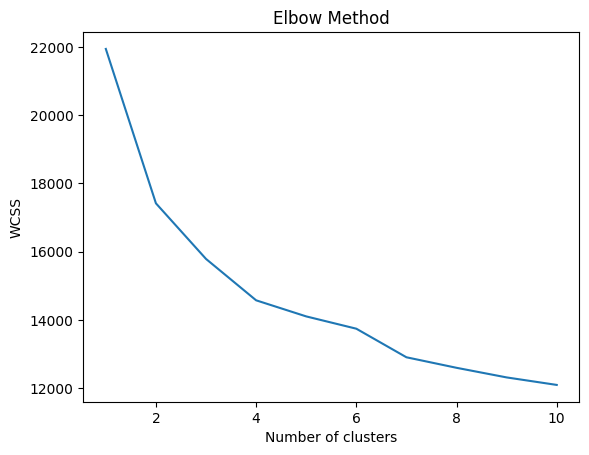

In [41]:
from sklearn.cluster import KMeans

wcss=[]
for i in range(1,11):
    dummy=KMeans(n_clusters=i,init="k-means++",random_state=0)
    dummy.fit(X)
    wcss.append(dummy.inertia_)

plt.title("Elbow Method")
plt.plot(range(1,11),wcss)
plt.ylabel("WCSS")
plt.xlabel("Number of clusters")
plt.show()

<i>Model building</i>

In [42]:
kmeans=KMeans(n_clusters=4,init="k-means++",random_state=0)
y_predict=kmeans.fit_predict(X)

<i>Plotting the graph</i>

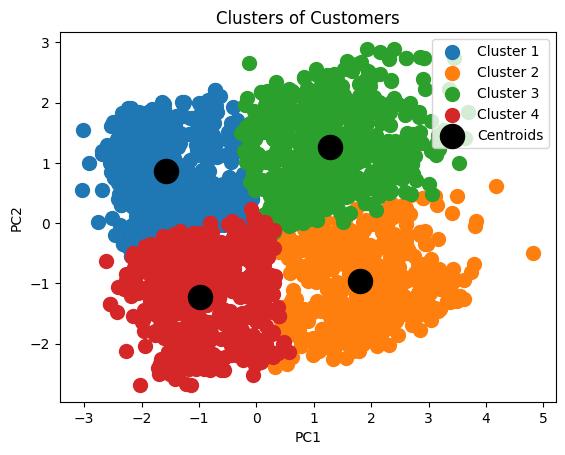

In [43]:
plt.scatter(X_pca[y_predict==0,0], X_pca[y_predict==0,1], s=100, label="Cluster 1")
plt.scatter(X_pca[y_predict==1,0], X_pca[y_predict==1,1], s=100, label="Cluster 2")
plt.scatter(X_pca[y_predict==2,0], X_pca[y_predict==2,1], s=100, label="Cluster 3")
plt.scatter(X_pca[y_predict==3,0], X_pca[y_predict==3,1], s=100, label="Cluster 4")

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=300, c="black", label="Centroids")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters of Customers")
plt.legend()
plt.show()

<i>Evaluation</i>

In [44]:
from sklearn.metrics import silhouette_score

print("Silhouette score:",silhouette_score(X,kmeans.fit_predict(X)))

Silhouette score: 0.13077268791364122


<b>Hierarchical Clustering</b>

<i>Using the dendrogram to find the optimal number of clusters</i>

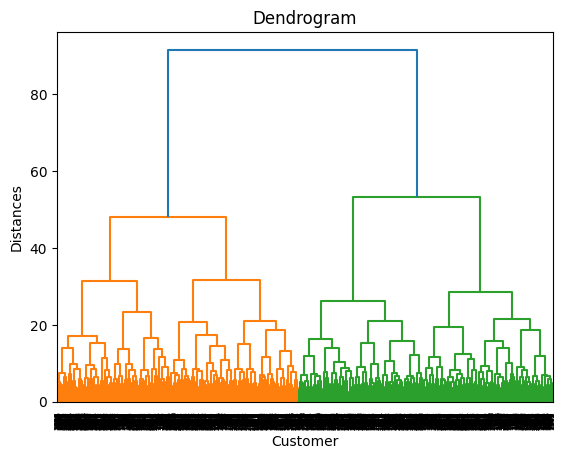

In [45]:
import scipy.cluster.hierarchy as sch

dendo=sch.dendrogram(sch.linkage(X,method="ward"))
plt.title("Dendrogram")
plt.xlabel("Customer")
plt.ylabel("Distances")
plt.show()

<i>Model building</i>

In [46]:
from sklearn.cluster import AgglomerativeClustering

cluster=AgglomerativeClustering(n_clusters=4,metric="euclidean",linkage="ward")
y_hc=cluster.fit_predict(X)

<i>Visualising the clusters</i>

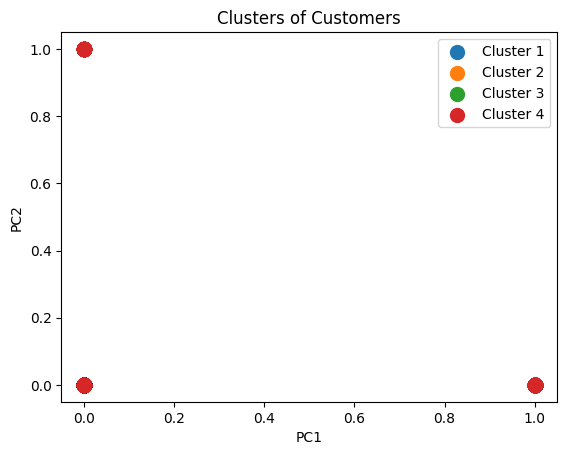

In [49]:
plt.scatter(X[y_hc==0,0],X[y_hc==0,1],s=100,label="Cluster 1")
plt.scatter(X[y_hc==1,0],X[y_hc==1,1],s=100,label="Cluster 2")
plt.scatter(X[y_hc==2,0],X[y_hc==2,1],s=100,label="Cluster 3")
plt.scatter(X[y_hc==3,0],X[y_hc==3,1],s=100,label="Cluster 4")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters of Customers")
plt.legend()
plt.show()

<i>Evaluation</i>

In [48]:
from sklearn.metrics import silhouette_score

print("Silhouette score:",silhouette_score(X,cluster.fit_predict(X)))

Silhouette score: 0.10901640054391708
